# Sistema de Recomendação Musical com FastAPI

**Atividade prática — implementada em Python com o dataset Top 50 Music de 2010 a 2019.**

Este notebook segue os requisitos do PDF e apresenta cinco APIs de recomendação: por características musicais, por gênero/artista, filtro colaborativo simulado, híbrida e popularidade/ano. Inclui exploração dos dados, documentação dos endpoints, exemplos e testes locais com `TestClient`.

> O CSV contém músicas populares e características musicais, mas não contém histórico real de usuários. Por isso, o endpoint colaborativo usa interações **simuladas e determinísticas**, agrupando faixas reais por gêneros para demonstrar co-ocorrências. Não se deve interpretar essa parte como comportamento real de ouvintes.

## 1. Preparação do ambiente

Coloque este notebook e `top50MusicFrom2010-2019.csv` na mesma pasta. O arquivo CSV anexado acompanha a entrega. Se necessário, instale as dependências em uma célula do Jupyter:

```python
%pip install pandas numpy scikit-learn fastapi uvicorn httpx matplotlib
```

O `TestClient` permite validar os endpoints sem iniciar um servidor externo.

In [ ]:
from pathlib import Path
import json
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from fastapi import FastAPI, HTTPException, Query
from pydantic import BaseModel, Field
from typing import Optional
from fastapi.testclient import TestClient

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

possible_paths = [
    Path("top50MusicFrom2010-2019.csv"),
    Path("top50MusicFrom2010-2019(1).csv"),
    Path("/home/ubuntu/upload/top50MusicFrom2010-2019.csv"),
]
CSV_PATH = next((p for p in possible_paths if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        "CSV não encontrado. Coloque top50MusicFrom2010-2019.csv na mesma pasta do notebook."
    )

raw_df = pd.read_csv(CSV_PATH)
print(f"Arquivo carregado: {CSV_PATH.resolve()}")
print(f"Dimensões originais: {raw_df.shape[0]} linhas × {raw_df.shape[1]} colunas")
print("Colunas originais:")
for col in raw_df.columns:
    print(" •", col)

Arquivo carregado: /content/top50MusicFrom2010-2019(1).csv
Dimensões originais: 603 linhas × 14 colunas
Colunas originais:
 • title
 • artist
 • the genre of the track
 • year
 • Beats.Per.Minute -The tempo of the song
 • Energy- The energy of a song - the higher the value, the more energtic
 • Danceability - The higher the value, the easier it is to dance to this song
 • Loudness/dB - The higher the value, the louder the song
 • Liveness - The higher the value, the more likely the song is a live recording
 • Valence - The higher the value, the more positive mood for the song
 • Length - The duration of the song
 • Acousticness - The higher the value the more acoustic the song is
 • Speechiness - The higher the value the more spoken word the song contains
 • Popularity- The higher the value the more popular the song is


In [ ]:
COLUMN_MAP = {
    "title": "title",
    "artist": "artist",
    "the genre of the track": "genre",
    "year": "year",
    "Beats.Per.Minute -The tempo of the song": "bpm",
    "Energy- The energy of a song - the higher the value, the more energtic": "energy",
    "Danceability - The higher the value, the easier it is to dance to this song": "danceability",
    "Loudness/dB - The higher the value, the louder the song": "loudness_db",
    "Liveness - The higher the value, the more likely the song is a live recording": "liveness",
    "Valence - The higher the value, the more positive mood for the song": "valence",
    "Length - The duration of the song": "length",
    "Acousticness - The higher the value the more acoustic the song is": "acousticness",
    "Speechiness - The higher the value the more spoken word the song contains": "speechiness",
    "Popularity- The higher the value the more popular the song is": "popularity",
}
missing_columns = [col for col in COLUMN_MAP if col not in raw_df.columns]
if missing_columns:
    raise ValueError(f"O CSV não contém as colunas esperadas: {missing_columns}")

df = raw_df.rename(columns=COLUMN_MAP)[list(COLUMN_MAP.values())].copy()
NUMERIC_COLUMNS = ["year", "bpm", "energy", "danceability", "loudness_db", "liveness",
                   "valence", "length", "acousticness", "speechiness", "popularity"]
for col in NUMERIC_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
for col in ["title", "artist", "genre"]:
    df[col] = df[col].astype("string").str.strip()

print(f"Dimensões após padronização: {df.shape[0]} linhas × {df.shape[1]} colunas")
print("Valores ausentes por coluna:")
display(df.isna().sum().to_frame("valores_ausentes").T)
print("\nAmostra:")
display(df.head())
assert len(df) > 0, "O dataset precisa conter pelo menos uma música."

Dimensões após padronização: 603 linhas × 14 colunas
Valores ausentes por coluna:


,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity
valores_ausentes,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Amostra:


,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,length,acousticness,speechiness,popularity
0,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78


## 2. Exploração rápida do dataset

A análise abaixo dá contexto ao sistema: distribuição anual das faixas e artistas com maior presença. Esses gráficos são exploratórios; as recomendações são calculadas diretamente a partir das faixas e atributos do CSV.

Período coberto: 2010 a 2019
Artistas distintos: 184
Gêneros distintos: 50
Gêneros mais frequentes:


,faixas
gênero,
dance pop,327
pop,60
canadian pop,34
barbadian pop,15
boy band,15
electropop,13
british soul,11
big room,10
canadian contemporary r&b,9


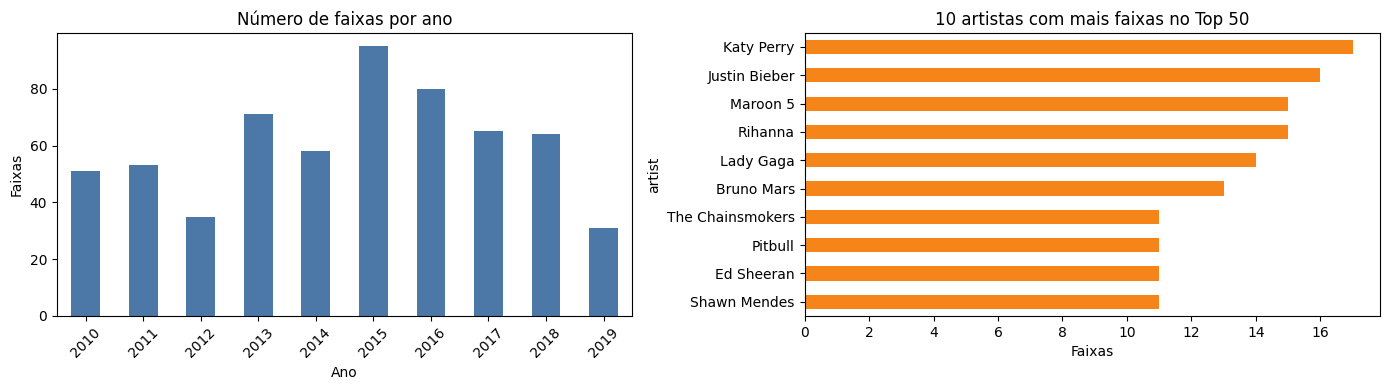

Popularidade média por ano:


,popularidade_média
year,
2010,64.25
2011,61.87
2012,67.77
2013,63.99
2014,62.71
2015,64.57
2016,64.16
2017,69.02
2018,72.44


In [ ]:
print("Período coberto:", int(df["year"].min()), "a", int(df["year"].max()))
print("Artistas distintos:", df["artist"].nunique())
print("Gêneros distintos:", df["genre"].nunique())
print("Gêneros mais frequentes:")
display(df["genre"].value_counts().head(10).rename_axis("gênero").to_frame("faixas"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("year").size().plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Número de faixas por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Faixas")
axes[0].tick_params(axis="x", rotation=45)
df.groupby("artist").size().sort_values(ascending=False).head(10).sort_values().plot(
    kind="barh", ax=axes[1], color="#f58518"
)
axes[1].set_title("10 artistas com mais faixas no Top 50")
axes[1].set_xlabel("Faixas")
plt.tight_layout()
plt.show()

print("Popularidade média por ano:")
display(df.groupby("year")["popularity"].mean().round(2).rename("popularidade_média").to_frame())

## 3. Pré-processamento e medidas de similaridade

Para conteúdo, são usadas as dez características indicadas no PDF: BPM, energia, danceabilidade, volume, vivacidade, valência, duração, acústica, fala e popularidade. A escala Min-Max coloca esses atributos em intervalos comparáveis. Os pesos opcionais podem ser informados como JSON na query string (`weights={"energy":2,"danceability":1}`); o cálculo multiplica cada característica pela raiz do peso antes da similaridade cosseno.

A comparação dos títulos ignora maiúsculas/minúsculas e espaços nas extremidades. A API exclui a própria faixa da lista de recomendações.

In [ ]:
FEATURES = ["bpm", "energy", "danceability", "loudness_db", "liveness",
            "valence", "length", "acousticness", "speechiness", "popularity"]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[FEATURES].astype(float))
FEATURE_ALIASES = {
    "bpm": "bpm", "beatsperminute": "bpm", "tempo": "bpm",
    "energy": "energy", "danceability": "danceability",
    "loudnessdb": "loudness_db", "loudness": "loudness_db", "volume": "loudness_db",
    "liveness": "liveness", "valence": "valence", "length": "length",
    "duration": "length", "acousticness": "acousticness",
    "speechiness": "speechiness", "popularity": "popularity",
}

def normalize_key(value: str) -> str:
    value = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]", "", value.lower())

def parse_weights(weights_json: Optional[str]) -> np.ndarray:
    weights = {feature: 1.0 for feature in FEATURES}
    if not weights_json:
        return np.array([weights[f] for f in FEATURES], dtype=float)
    try:
        provided = json.loads(weights_json)
    except json.JSONDecodeError as exc:
        raise HTTPException(status_code=400, detail="weights deve ser um objeto JSON válido.") from exc
    if not isinstance(provided, dict):
        raise HTTPException(status_code=400, detail="weights deve ser um objeto JSON de pesos.")
    for key, value in provided.items():
        feature = FEATURE_ALIASES.get(normalize_key(key))
        if feature is None:
            raise HTTPException(status_code=400, detail=f"Característica desconhecida em weights: {key}")
        try:
            value = float(value)
        except (TypeError, ValueError) as exc:
            raise HTTPException(status_code=400, detail=f"Peso inválido para {key}.") from exc
        if not np.isfinite(value) or value < 0:
            raise HTTPException(status_code=400, detail="Os pesos devem ser números finitos não negativos.")
        weights[feature] = value
    vector = np.array([weights[f] for f in FEATURES], dtype=float)
    if np.all(vector == 0):
        raise HTTPException(status_code=400, detail="Pelo menos um peso deve ser maior que zero.")
    return vector

def find_song_index(song_title: str) -> int:
    matches = df.index[df["title"].str.casefold() == song_title.strip().casefold()].tolist()
    if not matches:
        raise HTTPException(status_code=404, detail=f"Música não encontrada: {song_title}")
    return int(matches[0])

def music_record(index: int, score: Optional[float] = None) -> dict:
    row = df.iloc[int(index)]
    result = {
        "title": str(row["title"]), "artist": str(row["artist"]),
        "genre": str(row["genre"]), "year": int(row["year"]),
        "popularity": int(row["popularity"]),
    }
    if score is not None:
        result["score"] = round(float(score), 4)
    return result

def content_recommendations(song_title: str, limit: int = 5,
                            weights: Optional[np.ndarray] = None) -> list[dict]:
    song_index = find_song_index(song_title)
    weights = weights if weights is not None else np.ones(len(FEATURES), dtype=float)
    weighted_matrix = scaled_features * np.sqrt(weights)
    scores = cosine_similarity(weighted_matrix[song_index:song_index + 1], weighted_matrix)[0]
    order = np.argsort(-scores, kind="stable")
    selected = [int(i) for i in order if int(i) != song_index][:limit]
    return [music_record(i, scores[i]) for i in selected]

print("Características usadas:", FEATURES)
print("Matriz numérica normalizada:", scaled_features.shape)

Características usadas: ['bpm', 'energy', 'danceability', 'loudness_db', 'liveness', 'valence', 'length', 'acousticness', 'speechiness', 'popularity']
Matriz numérica normalizada: (603, 10)


## 4. Implementação das cinco APIs

| Endpoint | Método | Função |
|---|---|---|
| `/recommendations/content-based/{song_title}` | GET | Similaridade cosseno nas características musicais; `limit` e `weights` opcionais. |
| `/recommendations/genre-artist` | POST | Filtra por gênero **ou** artista e ordena por popularidade. |
| `/recommendations/collaborative/{user_id}` | GET | Soma co-ocorrências das interações simuladas de usuários vizinhos. |
| `/recommendations/hybrid` | POST | Combina os escores de conteúdo e colaboração com pesos definidos no corpo. |
| `/recommendations/popular` | GET | Ordena por popularidade, com filtro opcional de ano e/ou gênero. |

Os limites são restringidos a 1–50, e erros usuais (título ou usuário desconhecido, peso inválido) retornam códigos HTTP explicativos.

In [ ]:
class GenreArtistRequest(BaseModel):
    genre: Optional[str] = None
    artist: Optional[str] = None
    limit: int = Field(default=5, ge=1, le=50)

class HybridRequest(BaseModel):
    song_title: str
    user_id: str
    content_weight: float = Field(default=0.7, ge=0)
    collab_weight: float = Field(default=0.3, ge=0)
    limit: int = Field(default=5, ge=1, le=50)

app = FastAPI(
    title="Sistema de Recomendação Musical",
    description="Cinco estratégias de recomendação demonstrativas baseadas no dataset Top 50 Music 2010–2019.",
    version="1.0.0",
)

SIMULATED_USER_GENRES = {
    "user_01": ["dance pop", "pop"],
    "user_02": ["dance pop", "barbadian pop"],
    "user_03": ["pop", "neo mellow"],
    "user_04": ["dance pop", "canadian pop"],
    "user_05": ["detroit hip hop", "atl hip hop"],
    "user_06": ["dance pop", "art pop"],
}

def build_simulated_interactions() -> dict[str, set[int]]:
    interactions = {}
    for user_id, genres in SIMULATED_USER_GENRES.items():
        selected = df[df["genre"].str.casefold().isin([g.casefold() for g in genres])]
        selected = selected.sort_values(["popularity", "title"], ascending=[False, True])
        interactions[user_id] = set(int(i) for i in selected.head(15).index)
    return interactions

USER_LIKED_SONGS = build_simulated_interactions()

def collaborative_scores(user_id: str) -> dict[int, float]:
    if user_id not in USER_LIKED_SONGS:
        raise HTTPException(
            status_code=404,
            detail=f"Usuário '{user_id}' não existe nos dados simulados. Use um dos IDs documentados.",
        )
    target_likes = USER_LIKED_SONGS[user_id]
    scores: dict[int, float] = {}
    for other_id, other_likes in USER_LIKED_SONGS.items():
        if other_id == user_id:
            continue
        common = target_likes & other_likes
        if not common:
            continue
        neighbor_weight = float(len(common))
        for track_idx in other_likes - target_likes:
            scores[track_idx] = scores.get(track_idx, 0.0) + neighbor_weight
    return scores

@app.get("/recommendations/content-based/{song_title}")
def recommend_content(
    song_title: str,
    limit: int = Query(default=5, ge=1, le=50),
    weights: Optional[str] = Query(default=None, description='Pesos em JSON, ex.: {"energy":2,"danceability":1}'),
):
    parsed_weights = parse_weights(weights)
    return content_recommendations(song_title, limit, parsed_weights)

@app.post("/recommendations/genre-artist")
def recommend_genre_artist(request: GenreArtistRequest):
    if not request.genre and not request.artist:
        raise HTTPException(status_code=400, detail="Informe pelo menos genre ou artist.")
    mask = pd.Series(False, index=df.index)
    if request.genre:
        mask |= df["genre"].str.casefold() == request.genre.strip().casefold()
    if request.artist:
        mask |= df["artist"].str.casefold() == request.artist.strip().casefold()
    results = df[mask].sort_values(["popularity", "title"], ascending=[False, True]).head(request.limit)
    return [music_record(i) for i in results.index]

@app.get("/recommendations/collaborative/{user_id}")
def recommend_collaborative(
    user_id: str,
    limit: int = Query(default=5, ge=1, le=50),
):
    scores = collaborative_scores(user_id)
    ranked = sorted(scores, key=lambda idx: (-scores[idx], -float(df.iloc[idx]["popularity"]), str(df.iloc[idx]["title"])))
    return [music_record(i, scores[i]) for i in ranked[:limit]]

@app.post("/recommendations/hybrid")
def recommend_hybrid(request: HybridRequest):
    weight_sum = request.content_weight + request.collab_weight
    if weight_sum <= 0:
        raise HTTPException(status_code=400, detail="A soma dos pesos da recomendação híbrida deve ser maior que zero.")
    collab_raw = collaborative_scores(request.user_id)
    song_idx = find_song_index(request.song_title)
    content_matrix = scaled_features
    content_scores = cosine_similarity(
        content_matrix[song_idx:song_idx + 1], content_matrix
    )[0]
    content_raw = {int(i): float(score) for i, score in enumerate(content_scores) if i != song_idx}
    def normalize_scores(scores: dict[int, float]) -> dict[int, float]:
        if not scores:
            return {}
        values = np.asarray(list(scores.values()), dtype=float)
        lo, hi = float(values.min()), float(values.max())
        if hi == lo:
            return {key: 1.0 for key in scores}
        return {key: (float(value) - lo) / (hi - lo) for key, value in scores.items()}
    content_norm = normalize_scores(content_raw)
    collab_norm = normalize_scores(collab_raw)
    candidates = (set(content_norm) | set(collab_norm)) - {song_idx}
    combined = {}
    for track_idx in candidates:
        combined[track_idx] = (
            request.content_weight * content_norm.get(track_idx, 0.0)
            + request.collab_weight * collab_norm.get(track_idx, 0.0)
        ) / weight_sum
    ranked_indices = sorted(
        combined,
        key=lambda i: (-combined[i], -float(df.iloc[i]["popularity"]), str(df.iloc[i]["title"]), str(df.iloc[i]["artist"])),
    )
    return [music_record(i, combined[i]) for i in ranked_indices[:request.limit]]

@app.get("/recommendations/popular")
def recommend_popular(
    year: Optional[int] = Query(default=None, ge=2010, le=2019),
    genre: Optional[str] = Query(default=None),
    limit: int = Query(default=5, ge=1, le=50),
):
    results = df.copy()
    if year is not None:
        results = results[results["year"] == year]
    if genre:
        results = results[results["genre"].str.casefold() == genre.strip().casefold()]
    results = results.sort_values(["popularity", "title"], ascending=[False, True]).head(limit)
    return [music_record(i) for i in results.index]

print("Aplicação criada:", app.title)
print("Usuários simulados:", {user: len(tracks) for user, tracks in USER_LIKED_SONGS.items()})
print("Rotas:")
for route in app.routes:
    if getattr(route, "path", "").startswith("/recommendations/"):
        print(sorted(route.methods), route.path)

Aplicação criada: Sistema de Recomendação Musical
Usuários simulados: {'user_01': 15, 'user_02': 15, 'user_03': 15, 'user_04': 15, 'user_05': 7, 'user_06': 15}
Rotas:
['GET'] /recommendations/content-based/{song_title}
['POST'] /recommendations/genre-artist
['GET'] /recommendations/collaborative/{user_id}
['POST'] /recommendations/hybrid
['GET'] /recommendations/popular


## 5. Testes locais dos cinco endpoints

Os testes abaixo usam o `TestClient` do FastAPI, sem necessidade de subir um servidor. O usuário `user_01` (e os demais `user_02` a `user_06`) faz parte do conjunto de interações fictícias.

In [ ]:
client = TestClient(app)
example_song = str(df.iloc[0]["title"])
example_genre = str(df["genre"].value_counts().index[0])
example_year = int(df["year"].min())

response_content = client.get(f"/recommendations/content-based/{example_song}", params={"limit": 5})
assert response_content.status_code == 200, response_content.text
assert len(response_content.json()) == 5
response_weighted = client.get(
    f"/recommendations/content-based/{example_song}",
    params={"limit": 3, "weights": json.dumps({"energy": 2, "danceability": 1})},
)
assert response_weighted.status_code == 200, response_weighted.text

response_genre = client.post(
    "/recommendations/genre-artist",
    json={"genre": example_genre, "limit": 5},
)
assert response_genre.status_code == 200, response_genre.text
assert len(response_genre.json()) <= 5

response_collab = client.get("/recommendations/collaborative/user_01", params={"limit": 5})
assert response_collab.status_code == 200, response_collab.text
assert len(response_collab.json()) > 0

response_hybrid = client.post(
    "/recommendations/hybrid",
    json={"song_title": example_song, "user_id": "user_01", "content_weight": 0.7,
          "collab_weight": 0.3, "limit": 5},
)
assert response_hybrid.status_code == 200, response_hybrid.text
assert len(response_hybrid.json()) == 5

response_popular = client.get(
    "/recommendations/popular", params={"year": example_year, "genre": example_genre, "limit": 5}
)
assert response_popular.status_code == 200, response_popular.text
assert all(item["year"] == example_year for item in response_popular.json())
assert all(item["genre"].casefold() == example_genre.casefold() for item in response_popular.json())

assert client.get("/recommendations/content-based/titulo_inexistente").status_code == 404
assert client.get("/recommendations/collaborative/usuario_inexistente").status_code == 404

print("Todos os cinco endpoints responderam com sucesso.")
print("Teste de pesos personalizados, filtros e erros 404 também passou.")
for name, response in [
    ("conteúdo", response_content), ("gênero/artista", response_genre),
    ("colaborativo", response_collab), ("híbrido", response_hybrid),
    ("popularidade/ano", response_popular),
]:
    print(f"\nExemplo — {name} (HTTP {response.status_code}):")
    display(pd.DataFrame(response.json()).head(3))

Todos os cinco endpoints responderam com sucesso.
Teste de pesos personalizados, filtros e erros 404 também passou.

Exemplo — conteúdo (HTTP 200):


,title,artist,genre,year,popularity,score
0,Happier,Marshmello,brostep,2019,90,0.9938
1,Love Runs Out,OneRepublic,dance pop,2014,66,0.9933
2,The Heart Wants What It Wants,Selena Gomez,dance pop,2015,72,0.9929



Exemplo — gênero/artista (HTTP 200):


,title,artist,genre,year,popularity
0,Lose You To Love Me,Selena Gomez,dance pop,2019,97
1,Underneath the Tree,Kelly Clarkson,dance pop,2013,88
2,Don't Call Me Up,Mabel,dance pop,2019,86



Exemplo — colaborativo (HTTP 200):


,title,artist,genre,year,popularity,score
0,IDGAF,Dua Lipa,dance pop,2018,84,18.0
1,New Rules,Dua Lipa,dance pop,2018,84,18.0
2,no tears left to cry,Ariana Grande,dance pop,2018,84,18.0



Exemplo — híbrido (HTTP 200):


,title,artist,genre,year,popularity,score
0,Attention,Charlie Puth,dance pop,2018,83,0.9941
1,New Rules,Dua Lipa,dance pop,2018,84,0.9905
2,IDGAF,Dua Lipa,dance pop,2018,84,0.9768



Exemplo — popularidade/ano (HTTP 200):


,title,artist,genre,year,popularity
0,TiK ToK,Kesha,dance pop,2010,80
1,Bad Romance,Lady Gaga,dance pop,2010,79
2,Dynamite,Taio Cruz,dance pop,2010,77


## 6. Documentação interativa e execução do servidor

A documentação OpenAPI do FastAPI pode ser aberta em `http://127.0.0.1:8000/docs` quando o servidor estiver ativo. Para iniciar a API diretamente a partir do notebook, execute a célula abaixo **por último**; ela mantém o kernel ocupado até interromper a execução. Os testes acima já foram feitos localmente via `TestClient`.

Os exemplos de payloads também podem ser experimentados pela interface `/docs`:

```json
POST /recommendations/genre-artist
{"genre": "dance pop", "artist": null, "limit": 5}
```

```json
POST /recommendations/hybrid
{"song_title": "TiK ToK", "user_id": "user_01", "content_weight": 0.7, "collab_weight": 0.3, "limit": 5}
```

Para iniciar o servidor dentro do notebook, descomente e execute a chamada. Interrompa o kernel para encerrá-lo.

In [ ]:
# Descomente e execute quando quiser iniciar a API (a célula ficará executando):
# import uvicorn
# uvicorn.run(app, host="127.0.0.1", port=8000)

## 7. Observações e limitações

- Os dados descrevem faixas populares de 2010–2019; não representam todo o catálogo musical.
- As interações colaborativas são fictícias, derivadas de gêneros e popularidade do próprio CSV, conforme permitido no enunciado. Para produção, seria necessário histórico real de avaliações ou reproduções.
- Os pesos da recomendação por conteúdo aceitam os aliases `bpm`, `energy`, `danceability`, `loudness_db` (também `volume`), `liveness`, `valence`, `length` (também `duration`), `acousticness`, `speechiness` e `popularity`.
- A rota gênero/artista usa lógica **OU**: com os dois filtros, retorna músicas que correspondem ao gênero ou ao artista informado.
- A similaridade cosseno é uma demonstração simples; outras funções de distância e ajuste de pesos podem ser comparadas em estudos futuros.